In [5]:
from music21 import *

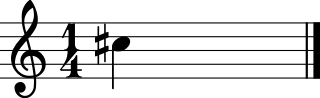

In [6]:
n = note.Note("C#5")
n.show()

Music generated successfully: predictable_music.mid


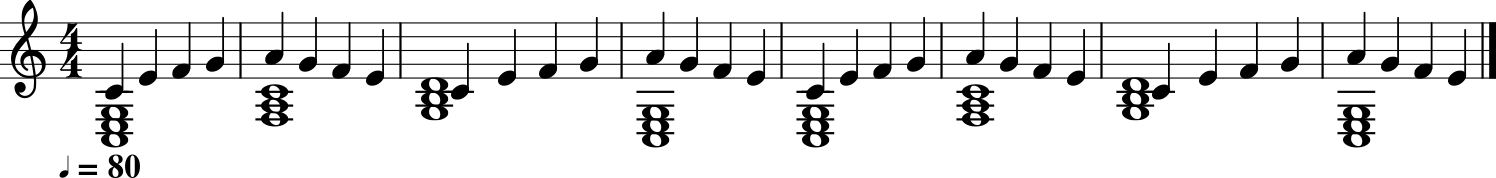

In [44]:
from music21 import stream, note, chord, meter, tempo, instrument, volume
score = stream.Score()
def generate_predictable_music(filename="predictable_music.mid", bpm=60):
    # 1. Initialize the Stream (Score)
 
    part = stream.Part()
    
    # 2. Set Instrument (Ensures no vocals/lyrics)
    part.insert(0, instrument.Piano())
    
    # 3. Set Constant Tempo (Range 50-80)
    # We will use 60 BPM for a very steady, predictable feel
    part.append(tempo.MetronomeMark(number=bpm))
    
    # 4. Set Time Signature (4/4)
    part.append(meter.TimeSignature('4/4'))
    
    # Define a simple, predictable chord progression (C - F - G - C)
    progression = [
        ['C3', 'E3', 'G3'], # C Major
        ['F3', 'A3', 'C4'], # F Major
        ['G3', 'B3', 'D4'], # G Major
        ['C3', 'E3', 'G3']  # C Major
    ]
    
    # Define a simple melody that follows the beats exactly
    melody_notes = ['C4', 'E4', 'F4', 'G4', 'A4', 'G4', 'F4', 'E4']

    # 5. Generate content with Constant Dynamics
    # We set a fixed velocity (volume) for every single note
    constant_velocity = 85 

    # Create 8 measures of predictable music
    for measure in range(8):
        # Determine which chord to use from the progression
        current_chord_notes = progression[measure % len(progression)]
        
        # Create a chord for the whole measure (4 beats) to keep it predictable
        c = chord.Chord(current_chord_notes)
        c.quarterLength = 4.0
        c.volume.velocity = constant_velocity
        
        # Alternatively, we can add a melody on top of the chords
        # This adds a note on every beat (Predictable beats)
        for i in range(4):
            m_note = note.Note(melody_notes[(measure * 4 + i) % len(melody_notes)])
            m_note.quarterLength = 1.0 # Exactly one beat
            m_note.volume.velocity = constant_velocity
            
            # Insert note and chord into the part
            # We offset the note by the current beat position
            part.insert(measure * 4 + i, m_note)
        
        # Insert the chord at the start of every measure
        part.insert(measure * 4, c)

    # Add the part to the score
    score.append(part)

    # 6. Write to MIDI file
    score.write('midi', fp=filename)
    print(f"Music generated successfully: {filename}")
    score.show()

if __name__ == "__main__":
    # You can change the bpm here (must be between 50 and 80)
    generate_predictable_music(bpm=80)

Dynamic yet constant music generated: dynamic_predictable.mid


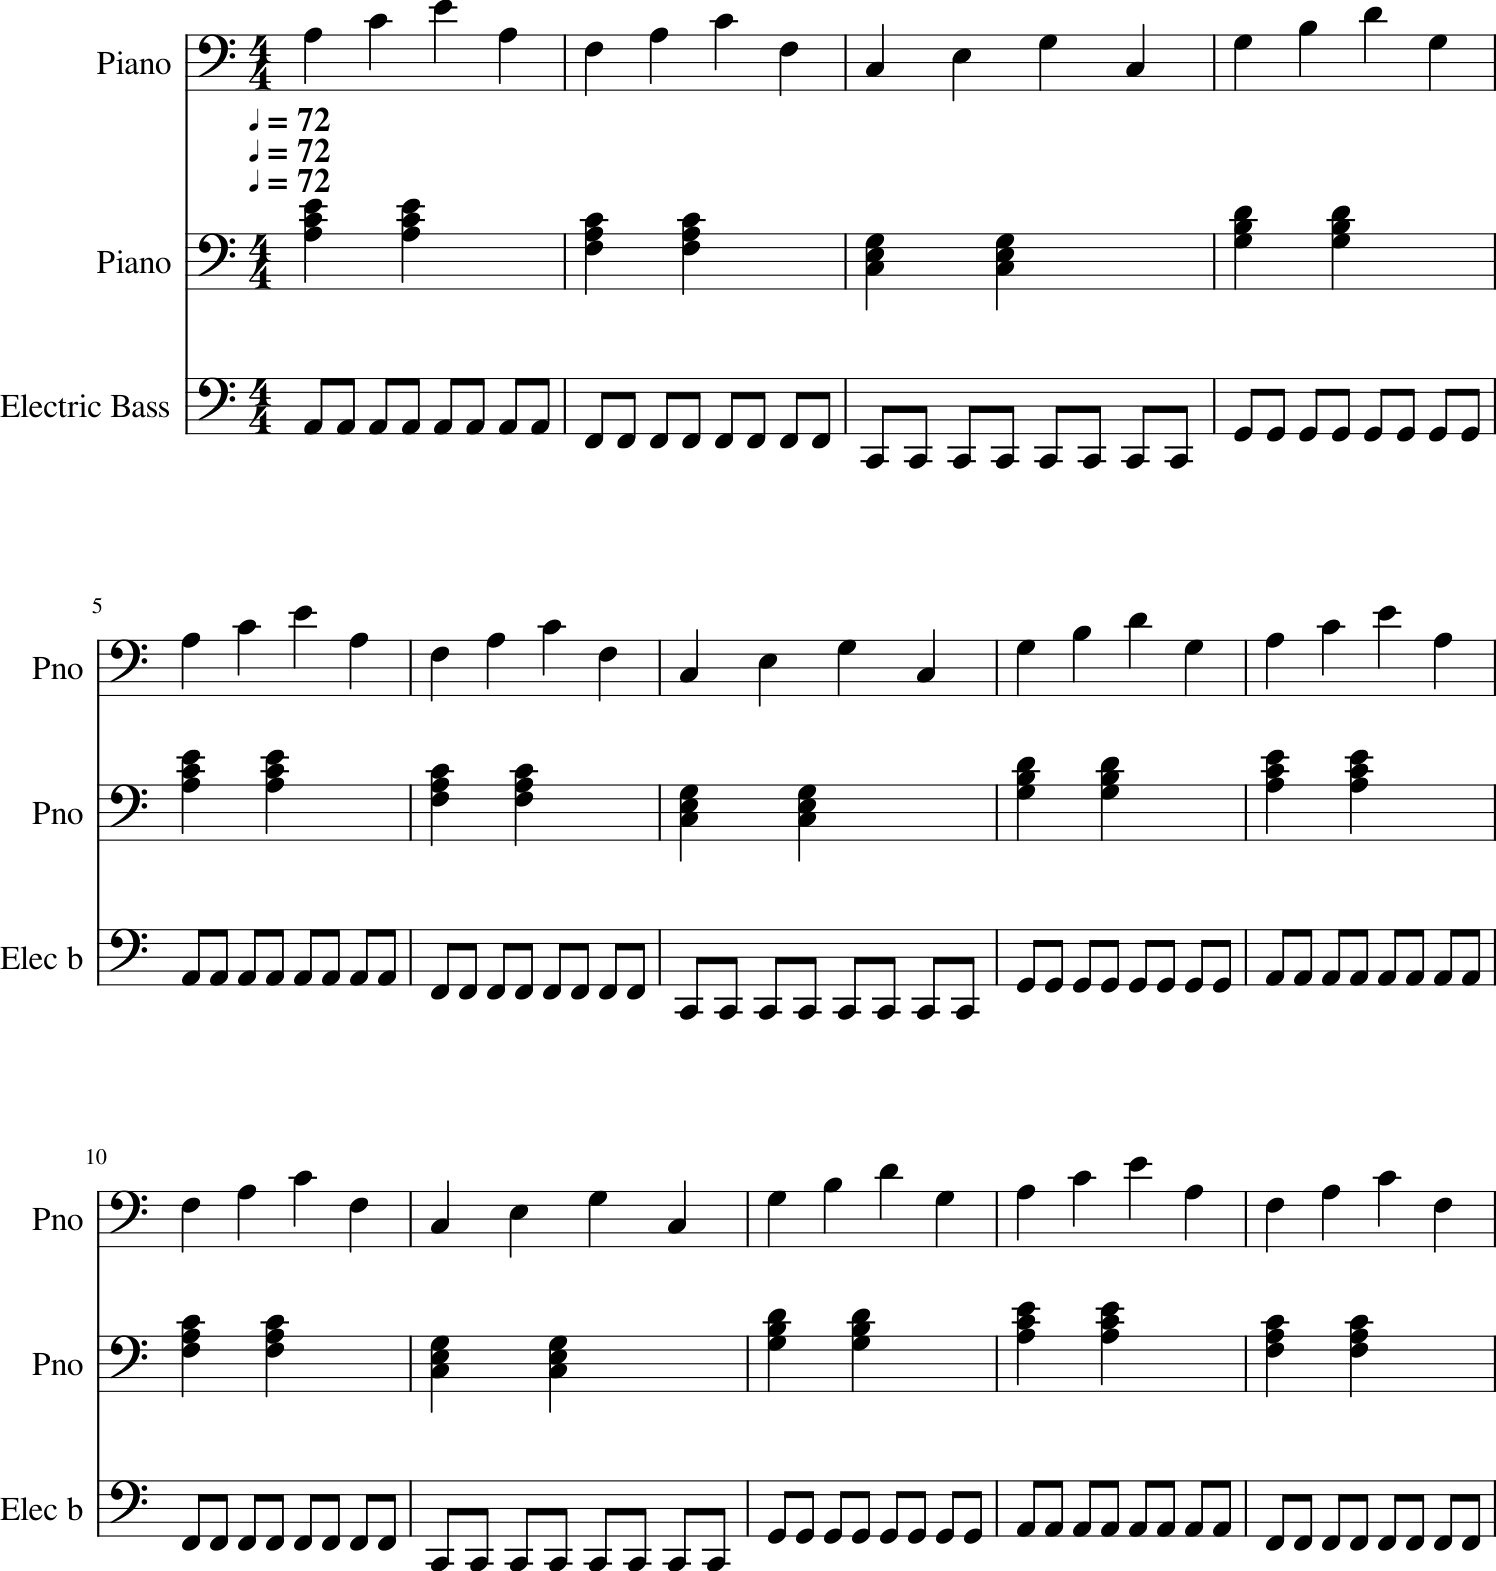

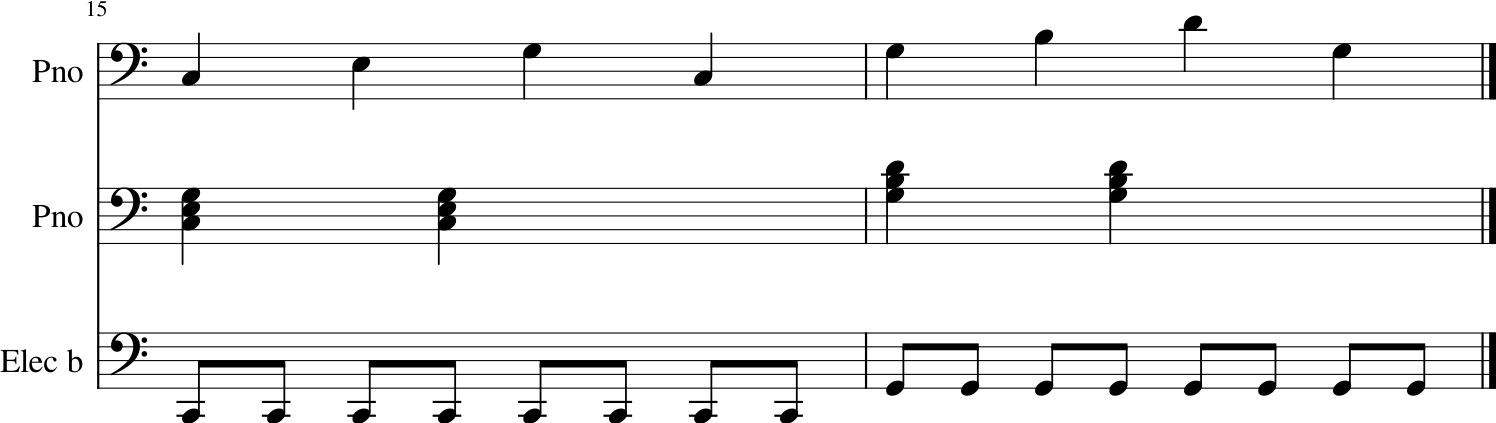

In [50]:
import random
from music21 import stream, note, chord, meter, tempo, instrument
score = stream.Score()
def generate_dynamic_predictable_music(filename="dynamic_predictable.mid", bpm=72):
    # Create a Score (Multi-part container)
 
    
    # Part 1: Piano Melody
    melody_part = stream.Part()
    melody_part.insert(0, instrument.Piano())
    
    # Part 2: Piano Chords (Accompaniment)
    chord_part = stream.Part()
    chord_part.insert(0, instrument.Piano())
    
    # Part 3: Electric Bass
    bass_part = stream.Part()
    bass_part.insert(0, instrument.ElectricBass())

    # Global settings
    for p in [melody_part, chord_part, bass_part]:
        p.append(tempo.MetronomeMark(number=bpm))
        p.append(meter.TimeSignature('4/4'))

    # Progression: Am - F - C - G (The "Epic" progression)
    progression = [
        {'root': 'A2', 'chord': ['A3', 'C4', 'E4']},
        {'root': 'F2', 'chord': ['F3', 'A3', 'C4']},
        {'root': 'C2', 'chord': ['C3', 'E3', 'G3']},
        {'root': 'G2', 'chord': ['G3', 'B3', 'D4']}
    ]

    fixed_velocity = 80 # Constant Dynamics

    # Generate 16 Measures
    for measure_idx in range(16):
        current = progression[measure_idx % len(progression)]
        offset = measure_idx * 4.0

        # --- 1. BASS LINE (Predictable Eighth Notes) ---
        # A steady 'walking' feel on every half-beat
        for i in range(8):
            b_note = note.Note(current['root'])
            b_note.quarterLength = 0.5
            b_note.volume.velocity = fixed_velocity
            bass_part.insert(offset + (i * 0.5), b_note)

        # --- 2. CHORD STABS (Predictable Syncopation) ---
        # Chords hit on beat 1 and the 'and' of beat 2
        for beat_offset in [0.0, 1.5]:
            c = chord.Chord(current['chord'])
            c.quarterLength = 1.0
            c.volume.velocity = fixed_velocity
            chord_part.insert(offset + beat_offset, c)

        # --- 3. MELODY (Arpeggiated Pattern) ---
        # Playing notes from the chord to keep it harmonious but active
        m_notes = current['chord'] + [current['chord'][0]] # Add octave
        for i in range(4):
            m_note = note.Note(m_notes[i % len(m_notes)])
            m_note.quarterLength = 1.0 # One note per beat
            m_note.volume.velocity = fixed_velocity
            melody_part.insert(offset + i, m_note)

    # Combine parts into score
    score.insert(0, melody_part)
    score.insert(0, chord_part)
    score.insert(0, bass_part)

    # Write MIDI
    score.write('midi', fp=filename)
    print(f"Dynamic yet constant music generated: {filename}")
    score.show()

if __name__ == "__main__":
    generate_dynamic_predictable_music()

In [39]:
s.show('midi')

In [48]:
score.show('midi')